In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import control



In [25]:
# Read Excel file
df = pd.read_excel('Lab 2 Frequency Response working.xlsx', usecols='C,F,H', header=0)
df.columns = ['omega', 'gain_dB', 'phase_deg']

omega     = df['omega'].values
gain_dB   = df['gain_dB'].values
phase_deg = df['phase_deg'].values



OLS Optimisation for k

In [ ]:
# Poles obtained from graph paper
w1 = 10   
w2 = 32  

# Only fit K
def tf_model_fixed_poles(omega, K):
    jw = 1j * omega
    H_model = K / ((1 + jw/w1) * (1 + jw/w2))
    return np.concatenate([np.real(H_model), np.imag(H_model)])

H_stacked = np.concatenate([np.real(H), np.imag(H)])
params, _ = curve_fit(tf_model_fixed_poles, omega, H_stacked, p0=[1.0])
K_fit = params[0]

print(f'K  = {K_fit:.4f}')

K  = 1.0647


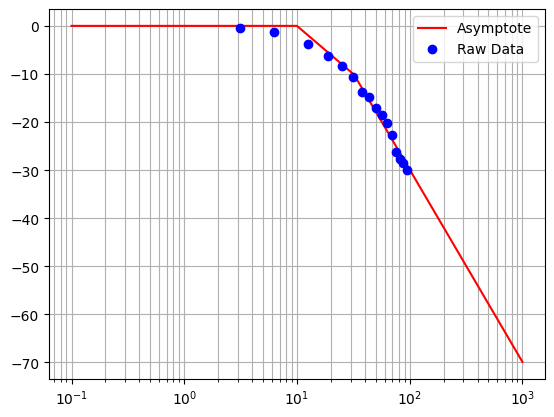

In [ ]:
# Asymptotically create Bode plot 
# Your manually identified values
K  = 1.0
w1 = 10   # read from plot
w2 = 32  # read from plot

omega_plot = np.logspace(-1, 3, 1000)

# Asymptotic gain — piecewise straight lines
gain_asymptote = np.zeros_like(omega_plot)
for i, w in enumerate(omega_plot):
    if w < w1:
        gain_asymptote[i] = 20*np.log10(K)           # flat
    elif w < w2:
        gain_asymptote[i] = 20*np.log10(K) - 20*np.log10(w/w1)   # -20dB/dec
    else:
        gain_asymptote[i] = 20*np.log10(K) - 20*np.log10(w2/w1) - 40*np.log10(w/w2)  # -40dB/dec

plt.semilogx(omega_plot, gain_asymptote, 'r-', label='Asymptote')
plt.semilogx(omega, gain_dB, 'bo', label='Raw Data')
plt.grid(True, which='both')
plt.legend()
plt.show()

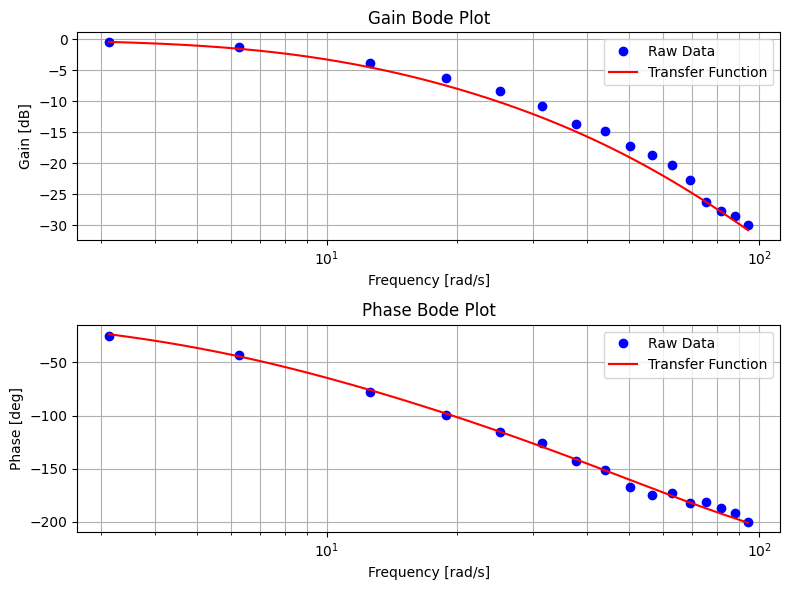

In [ ]:
# Create Bode plot from transfer function using curve_fit
# Your identified transfer function parameters
K  = 1.0
w1 = 10.0
w2 = 58

# Generate smooth frequency range for TF curve
omega_plot = np.logspace(np.log10(min(omega)), np.log10(max(omega)), 1000)

# Evaluate transfer function
jw = 1j * omega_plot
H_tf = K / ((1 + jw/w1) * (1 + jw/w2) ** 2)

# Compute gain and phase of TF
gain_tf   = 20*np.log10(np.abs(H_tf))
phase_tf = np.rad2deg(np.unwrap(np.angle(H_tf)))

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# Gain plot
ax1.semilogx(omega, gain_dB, 'bo', label='Raw Data')
ax1.semilogx(omega_plot, gain_tf, 'r-', label='Transfer Function')
ax1.set_ylabel('Gain [dB]')
ax1.set_xlabel('Frequency [rad/s]')
ax1.legend()
ax1.grid(True, which='both')
ax1.set_title('Gain Bode Plot')

# Phase plot
ax2.semilogx(omega, phase_deg, 'bo', label='Raw Data')
ax2.semilogx(omega_plot, phase_tf, 'r-', label='Transfer Function')
ax2.set_ylabel('Phase [deg]')
ax2.set_xlabel('Frequency [rad/s]')
ax2.legend()
ax2.grid(True, which='both')
ax2.set_title('Phase Bode Plot')

plt.tight_layout()
plt.show()